<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/Practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install & download YOLOv3-tiny (fast, good for Colab) weights/cfg/names
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3-tiny.cfg -O yolov3-tiny.cfg
!wget -q https://pjreddie.com/media/files/yolov3-tiny.weights -O yolov3-tiny.weights
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names -O coco.names

import cv2, numpy as np, time
import matplotlib.pyplot as plt
print("OpenCV version:", cv2.__version__)

OpenCV version: 4.14.0


Image shape: (1080, 810, 3)


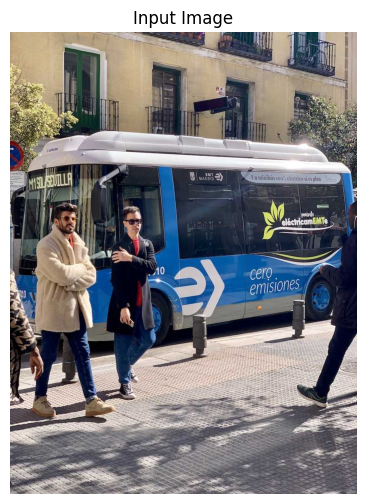

In [ ]:
# Cell 2: Get input image — robust version with working URLs + synthetic fallback
from google.colab import files
import os

use_sample = True  # set False to upload your own image

def download_sample():
    urls = [
        "https://ultralytics.com/images/bus.jpg",
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/box.png",
    ]
    for url in urls:
        os.system(f'wget -q "{url}" -O input.jpg')
        if os.path.exists("input.jpg") and os.path.getsize("input.jpg") > 1000:
            test = cv2.imread("input.jpg")
            if test is not None:
                return True
    return False

def make_synthetic_boxes_image():
    # Creates a synthetic "warehouse packages" image with rectangles (boxes)
    canvas = np.full((480, 640, 3), 200, dtype=np.uint8)  # gray floor
    boxes_data = [
        (50, 300, 150, 420, (19, 69, 139)),
        (180, 280, 300, 430, (0, 140, 255)),
        (330, 310, 430, 420, (42, 42, 165)),
        (450, 290, 580, 410, (30, 105, 210)),
        (100, 150, 220, 260, (19, 69, 139)),
        (350, 140, 460, 250, (0, 140, 255)),
    ]
    for (x1, y1, x2, y2, color) in boxes_data:
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, -1)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 0, 0), 3)
    cv2.imwrite("input.jpg", canvas)

if use_sample:
    import cv2, numpy as np
    ok = download_sample()
    if not ok:
        print("Download failed — generating synthetic packages image instead.")
        make_synthetic_boxes_image()
else:
    uploaded = files.upload()
    input_path = list(uploaded.keys())[0]
    os.rename(input_path, "input.jpg")

img = cv2.imread("input.jpg")
assert img is not None, "input.jpg still failed to load — check the path/upload."
print("Image shape:", img.shape)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis('off')
plt.show()

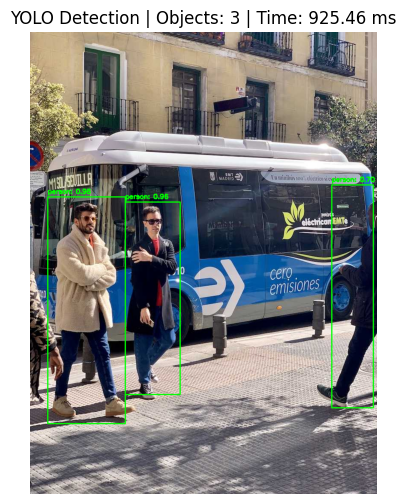

In [ ]:
# Cell 3: YOLO object detection using OpenCV DNN module
def load_yolo():
    net = cv2.dnn.readNet("yolov3-tiny.weights", "yolov3-tiny.cfg")
    layer_names = net.getLayerNames()
    out_layers = net.getUnconnectedOutLayers()
    output_layers = [layer_names[i - 1] for i in out_layers.flatten()]
    with open("coco.names", "r") as f:
        classes = [line.strip() for line in f.readlines()]
    return net, output_layers, classes

def yolo_detect(img, net, output_layers, classes, conf_threshold=0.4, nms_threshold=0.4):
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)

    start = time.time()
    outputs = net.forward(output_layers)
    infer_time = time.time() - start

    boxes, confidences, class_ids = [], [], []
    for output in outputs:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > conf_threshold:
                cx, cy = int(detection[0]*w), int(detection[1]*h)
                bw, bh = int(detection[2]*w), int(detection[3]*h)
                x, y = int(cx - bw/2), int(cy - bh/2)
                boxes.append([x, y, bw, bh])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
    result_img = img.copy()
    count = 0
    if len(indices) > 0:
        for i in indices.flatten():
            x, y, bw, bh = boxes[i]
            label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
            cv2.rectangle(result_img, (x, y), (x+bw, y+bh), (0, 255, 0), 2)
            cv2.putText(result_img, label, (x, max(y-8,0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
            count += 1
    return result_img, count, infer_time

net, output_layers, classes = load_yolo()
yolo_result, yolo_count, yolo_time = yolo_detect(img, net, output_layers, classes)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(yolo_result, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Detection | Objects: {yolo_count} | Time: {yolo_time*1000:.2f} ms")
plt.axis('off')
plt.show()

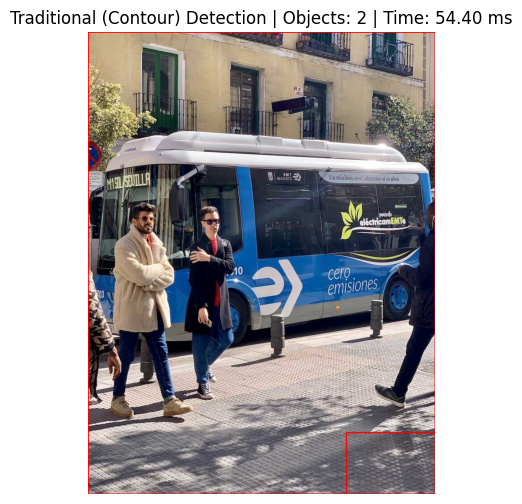

In [ ]:
# Cell 4: Traditional method — grayscale + Canny edge + contour based box/package detection
def traditional_detect(img, min_area=1500):
    start = time.time()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    dilated = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result_img = img.copy()
    count = 0
    for c in contours:
        area = cv2.contourArea(c)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 0, 255), 2)
            count += 1
    infer_time = time.time() - start
    return result_img, count, infer_time, edges

trad_result, trad_count, trad_time, edges = traditional_detect(img)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(trad_result, cv2.COLOR_BGR2RGB))
plt.title(f"Traditional (Contour) Detection | Objects: {trad_count} | Time: {trad_time*1000:.2f} ms")
plt.axis('off')
plt.show()

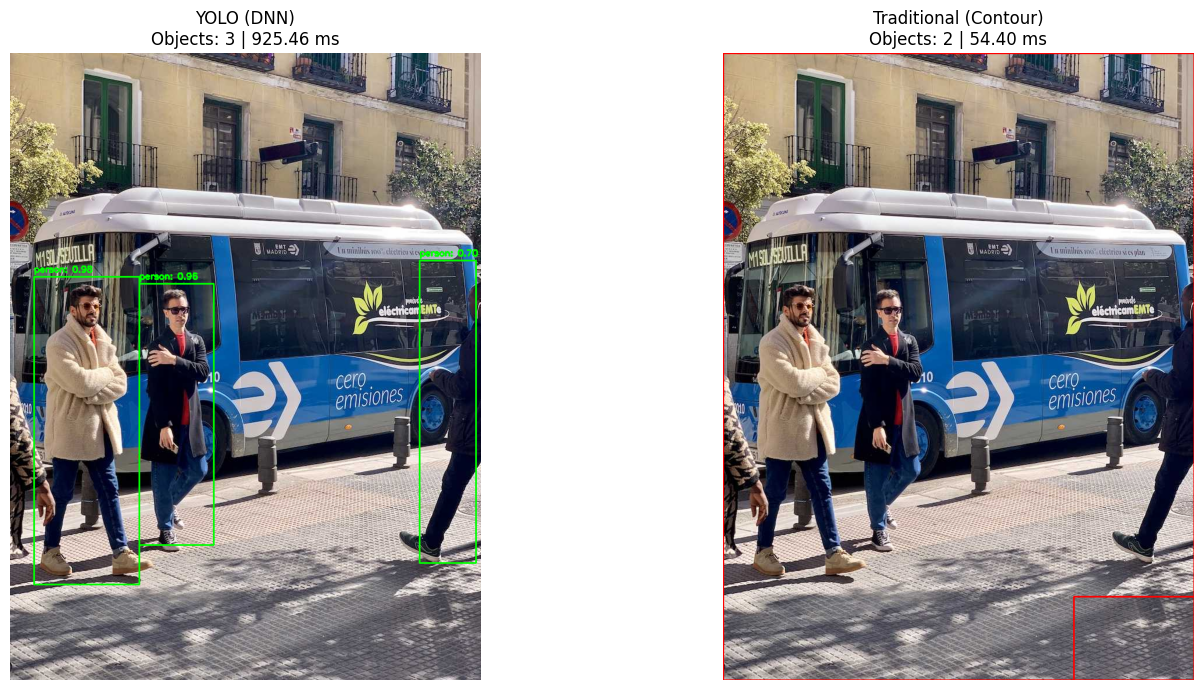

Method                   Objects Detected    Time (ms)
YOLO (OpenCV DNN)        3                   925.46
Traditional (Contour)    2                   54.40
YOLO is 0.06x slower than traditional method,
but gives class labels + confidence scores + better accuracy on real packages/objects.


In [ ]:
# Cell 5: Compare both side by side + performance metrics
fig, axs = plt.subplots(1, 2, figsize=(16,7))
axs[0].imshow(cv2.cvtColor(yolo_result, cv2.COLOR_BGR2RGB))
axs[0].set_title(f"YOLO (DNN)\nObjects: {yolo_count} | {yolo_time*1000:.2f} ms")
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(trad_result, cv2.COLOR_BGR2RGB))
axs[1].set_title(f"Traditional (Contour)\nObjects: {trad_count} | {trad_time*1000:.2f} ms")
axs[1].axis('off')
plt.tight_layout()
plt.show()

print("="*55)
print(f"{'Method':<25}{'Objects Detected':<20}{'Time (ms)'}")
print("="*55)
print(f"{'YOLO (OpenCV DNN)':<25}{yolo_count:<20}{yolo_time*1000:.2f}")
print(f"{'Traditional (Contour)':<25}{trad_count:<20}{trad_time*1000:.2f}")
print("="*55)
print(f"YOLO is {trad_time/yolo_time:.2f}x {'slower' if yolo_time>trad_time else 'faster'} than traditional method,")
print("but gives class labels + confidence scores + better accuracy on real packages/objects.")